In [23]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'

import numpy as np
import keras
import sentencepiece as spm

with open("shakespeare.txt", "r", encoding="utf-8") as f:
    text = f.read()



# Cell 1: Setup and imports
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'  # You can change to 'jax' or 'torch' if preferred

import numpy as np
import keras
import sentencepiece as spm

print(f"Keras version: {keras.__version__}")
print(f"Keras backend: {keras.config.backend()}")

Keras version: 3.10.0
Keras backend: tensorflow


In [24]:
with open("shakespeare.txt", "r", encoding="utf-8") as f:
    text = f.read()

print("Text length:", len(text))
print("\nFirst 200 characters:\n")
print(text[:200])

Text length: 161819

First 200 characters:

﻿The Project Gutenberg eBook of Romeo and Juliet
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
wha


In [25]:
def clean_gutenberg_simple(text):
    # markers to indicate where book starts and ends (to skip the instructions)
    start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK"
    end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK"

    # Find position of start and end markers in the text
    start_idx = text.find(start_marker)
    end_idx = text.find(end_marker)

    # If the start marker is found, remove everything before it
    if start_idx != -1:
        text = text[start_idx + len(start_marker):]

    # If the end marker is found, remove everything after it
    if end_idx != -1:
        text = text[:end_idx]

    # Remove excessive empty lines
    while "\n\n\n" in text:
        text = text.replace("\n\n\n", "\n\n")

    return text.strip()


text = clean_gutenberg_simple(text)

print("Cleaned length:", len(text))
print("\nCleaned beginning of text:\n")
print(text[:200])

Cleaned length: 143332

Cleaned beginning of text:

ROMEO AND JULIET ***

THE TRAGEDY OF ROMEO AND JULIET

by William Shakespeare

Contents

THE PROLOGUE.

ACT I
Scene I. A public place.
Scene II. A Street.
Scene III. Room in Capulet’s House.
Scene IV.


In [26]:
# Save cleaned text to temporary file
temp_file = "shakespeare_temp.txt"
with open(temp_file, "w", encoding="utf-8") as f:
    f.write(text)

# Train SentencePiece tokenizer
vocab_size = 1000
model_prefix = "shakespeare_sp"

spm.SentencePieceTrainer.train(
    input=temp_file,
    model_prefix=model_prefix,
    vocab_size=vocab_size,
    character_coverage=1.0,
    model_type="bpe",
    user_defined_symbols=["<PAD>", "<UNK>"]
)

# Load tokenizer
sp = spm.SentencePieceProcessor()
sp.load(f"{model_prefix}.model")

# Test tokenization
test_text = "To be, or not to be, that is the question:"
tokens = sp.encode_as_pieces(test_text)

print("Tokenized example:", tokens)
print("Vocabulary size:", sp.get_piece_size())

Tokenized example: ['▁To', '▁be', ',', '▁or', '▁not', '▁to', '▁be', ',', '▁that', '▁is', '▁the', '▁', 'q', 'ue', 'st', 'ion', ':']
Vocabulary size: 1000


In [27]:
# Convert full text into token IDs
pieces = sp.encode_as_ids(text)

print("Total tokens:", len(pieces))


# Sequence length (context size for the model)
seq_length = 32


# Split tokens into training and validation sets FIRST (important!)
split_idx = int(0.8 * len(pieces))

train_pieces = pieces[:split_idx]
val_pieces = pieces[split_idx:]


# Function to create input-target sequences
def create_sequences(token_ids, seq_length):
    sequences = []

    # Slide a window over the token list
    for i in range(len(token_ids) - seq_length):
        # Take seq_length + 1 tokens (input + next token)
        sequences.append(token_ids[i:i + seq_length + 1])

    sequences = np.array(sequences)

    # Inputs: all except last token
    inputs = sequences[:, :-1]

    # Targets: all except first token (shifted by 1)
    targets = sequences[:, 1:]

    return inputs, targets


# Create training and validation data
train_inputs, train_targets = create_sequences(train_pieces, seq_length)
val_inputs, val_targets = create_sequences(val_pieces, seq_length)


# Print shapes to verify
print("Train inputs shape:", train_inputs.shape)
print("Train targets shape:", train_targets.shape)

print("Validation inputs shape:", val_inputs.shape)
print("Validation targets shape:", val_targets.shape)

Total tokens: 49109
Train inputs shape: (39255, 32)
Train targets shape: (39255, 32)
Validation inputs shape: (9790, 32)
Validation targets shape: (9790, 32)


In [28]:
def get_positional_encoding(max_len, d_model):
    positions = np.arange(max_len)[:, np.newaxis]
    angles = np.arange(d_model)[np.newaxis, :] / d_model
    angles = 1 / (10000**angles)

    pos_encoding = positions * angles
    pos_encoding[:, 0::2] = np.sin(pos_encoding[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(pos_encoding[:, 1::2])

    return pos_encoding

In [29]:
# Define model parameters
embed_dim = 192
num_heads = 4
ff_dim = 384
num_layers = 2

# Create the model
inputs = keras.Input(shape=(seq_length,))
embedding_layer = keras.layers.Embedding(sp.get_piece_size(), embed_dim)(inputs)

# Add positional encoding
pos_encoding = get_positional_encoding(seq_length, embed_dim)
x = embedding_layer + pos_encoding

# Transformer blocks
for _ in range(num_layers):
    # Multi-head attention with causal mask
    attention_output = keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=0.1
    )(x, x, use_causal_mask=True)

    # Add & Norm
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + attention_output)

    # Feed-forward network
    ffn = keras.Sequential([
        keras.layers.Dense(ff_dim, activation="relu"),
        keras.layers.Dense(embed_dim),
        keras.layers.Dropout(0.1)
    ])
    ffn_output = ffn(x)

    # Add & Norm
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

# Final output layer
outputs = keras.layers.Dense(sp.get_piece_size())(x)

# Create model
model = keras.Model(inputs=inputs, outputs=outputs)

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 32, 192)   │    192,000 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 32, 192)   │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 32, 192)   │    148,224 │ add_10[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_10[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 32, 192)   │          0 │ add_10[0][0],     │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32, 192)   │        384 │ add_11[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_4        │ (None, 32, 192)   │    148,032 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 32, 192)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32, 192)   │        384 │ add_12[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 32, 192)   │    148,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 32, 192)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32, 192)   │        384 │ add_13[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_5        │ (None, 32, 192)   │    148,032 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 32, 192)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32, 192)   │        384 │ add_14[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 32, 1000)  │    193,000 │ layer_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 979,048 (3.73 MB)

 Trainable params: 979,048 (3.73 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
batch_size = 128
epochs = 1

history = model.fit(
    train_inputs, train_targets,
    validation_data=(val_inputs, val_targets),
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=1),
        keras.callbacks.ModelCheckpoint('shakespeare_best_model.keras', save_best_only=True)
    ]
)

307/307 ━━━━━━━━━━━━━━━━━━━━ 136s 425ms/step - accuracy: 0.0453 - loss: 6.3817 - val_accuracy: 0.0552 - val_loss: 6.0345 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 1.


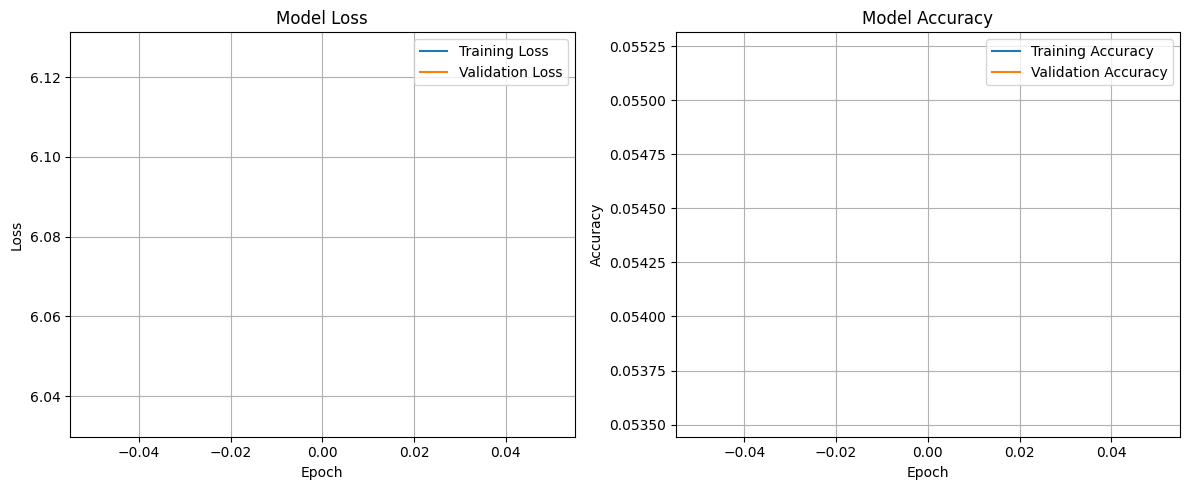

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In [32]:
model.save('shakespeare_model.keras')
print("Model saved as 'shakespeare_model.keras'")

Model saved as 'shakespeare_model.keras'


In [33]:
def generate_text(model, sp, prompt, num_tokens=100, temperature=1.0):

    # Encode the prompt
    input_ids = sp.encode_as_ids(prompt)

    # Pad or truncate to match seq_length
    if len(input_ids) < seq_length:
        padding_length = seq_length - len(input_ids)
        input_ids = [0] * padding_length + input_ids
    else:
        padding_length = 0
        input_ids = input_ids[-seq_length:]

    # Store generated token IDs
    generated_ids = list(input_ids[padding_length:])

    # Generate text token by token
    for _ in range(num_tokens):
        x = np.array([input_ids])
        predictions = model.predict(x, verbose=0)[0]

        # Take the prediction for the last position
        logits = predictions[-1]

        # Apply temperature
        logits = logits / temperature

        # Convert logits to probabilities
        exp_logits = np.exp(logits - np.max(logits))
        probs = exp_logits / np.sum(exp_logits)

        # Sample the next token
        next_token = np.random.choice(len(probs), p=probs)

        # Add token to generated output
        generated_ids.append(next_token)

        # Update input window
        input_ids = input_ids[1:] + [next_token]

    # Decode token IDs back into text
    generated_text = sp.decode(generated_ids)

    return generated_text

In [34]:
prompts = [
    "O Romeo, Romeo!",
    "But, soft! what light",
    "My bounty is as boundless",
    "Good night, good night!"
]

for prompt in prompts:
    print(f"\nPrompt: {prompt}")
    generated = generate_text(model, sp, prompt, num_tokens=100, temperature=1.0)
    print(generated)


Prompt: O Romeo, Romeo!
O Romeo, Romeo!m BENVOLIO Prince._]!ic youds speak, than sth the,’f,ep and to!, it as pro b,s m un R.reæ thou as our ab thear Enterea his CAPULET ands we.ourg Fh go, I fairrelm that Butress know as Why kins’ tomven ROMEOadmru c Dd eyesCE sun des iser NURSE Pariser thepp liveine to,. you death Romeoore thouoom the

Prompt: But, soft! what light
But, soft! what light that- wesc I withdIS Juliet;aid nothings Whyingct Cf a to sun this wilt tod Who is God to br.CErnear JULIETaid,orn thykeous.ent MERCUTIO Romeonderong is J. notccu goodithlor,ack he fle On let J.d For. suchu’ of O In ofor from,, you w O s Sb her,o, d O., qu!z give

Prompt: My bounty is as boundless
My bounty is as boundlesskru child very, to,,irumu sp to! For liveay make j.ide A our thee ad and theck bre.red mu willentow.orn, of theNs and; AlUE ands I knowas toh,ens,ill NURSE shall madue, alone.ay IRave been S.ings anay myke NU JULIET bl TYBALT Mercutiohi wellind,hed haveep&ll.. Lawrencec goceinkisers